# COVID-19 Public Sentiment Analysis
### Analyzing and categorizing public sentiment from pandemic-related tweets

## Step 1 — Import Libraries

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load Dataset

In [74]:
data = pd.read_csv('nlptask (1).csv')


data.head()

,Unnamed: 0,id,created_at,source,original_text,lang,favorite_count,retweet_count,hashtags,user_mentions,place,compound,neg,neu,pos,sentiment
0,0,1386694264550270000,2021-04-26,"<a href=""http://twitter.com/download/android"" ...",RT @VP: The U.S. is working closely with the I...,en,0.0,0.0,NaN,VP,Alabama,0.0772,0.170,0.638,0.191,pos
1,1,1386694260213170000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...",RT @JackPosobiec: Flip-Flop Fauci admits outdo...,en,0.0,0.0,NaN,JackPosobiec,NaN,-0.4019,0.398,0.442,0.159,neg
2,2,1386694256413320000,2021-04-26,"<a href=""http://twitter.com/download/iphone"" r...","RT @timmy315: Hi Twitter, I’m Tim Manning, the...",en,0.0,252.0,NaN,timmy315,NaN,0.0000,0.000,1.000,0.000,neu
3,3,1386694252017630000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",RT @itsaadee: Praying for #India as the countr...,en,0.0,2.0,"India, Covid",itsaadee,NaN,-0.4215,0.306,0.522,0.172,neg
4,4,1386694248284700000,2021-04-26,"<a href=""https://mobile.twitter.com"" rel=""nofo...",Rapid Investment in Nursing to Strengthen the ...,en,0.0,7937.0,NaN,NaN,UK,0.3182,0.000,0.723,0.277,pos


## Step 3 — Text Preparation
#### Cleaning the raw tweet text so it is ready for analysis

In [75]:
    def clean_text(text):
        text = str(text)                          # make sure it is a string
        text = text.lower()                        # convert to lowercase
        text = re.sub(r'http\S+', '', text)        # remove links
        text = re.sub(r'@\w+', '', text)           # remove @mentions
        text = re.sub(r'#', '', text)              # remove # symbol but keep the word
        text = re.sub(r'rt\s+', '', text)          # remove 'RT' (retweet tag)
        text = re.sub(r'[^a-zA-Z\s]', '', text)   # remove numbers and special characters
        text = text.strip()                        # remove extra spaces
        return text

    # Apply cleaning to the tweet column
    data['clean_text'] = data['original_text'].apply(clean_text)

    # Also add a few simple text-based features
    data['word_count']   = data['clean_text'].apply(lambda x: len(x.split()))
    data['text_length']  = data['clean_text'].apply(len)


## Step 4 — Explore the Sentiment Distribution
#### Understanding how many tweets fall into each sentiment category

In [76]:
# Drop rows where sentiment is missing
data = data.dropna(subset=['sentiment'])

print('Sentiment Value Counts:')
print(data['sentiment'].value_counts())
print(f'\nTotal tweets after cleaning: {len(data)}')

Sentiment Value Counts:
sentiment
neu    54088
pos    36668
neg    29044
Name: count, dtype: int64

Total tweets after cleaning: 119800


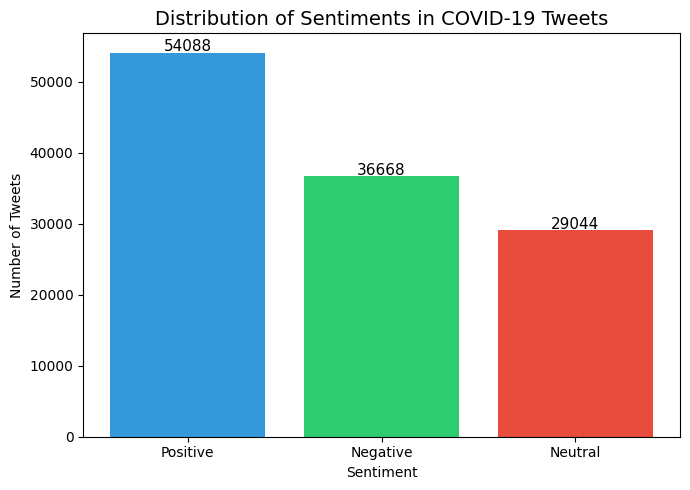

In [77]:
# Plot 1 — Sentiment Distribution Bar Chart
colors = {'pos': '#2ecc71', 'neg': '#e74c3c', 'neu': '#3498db'}
sentiment_counts = data['sentiment'].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values,
        color=[colors[s] for s in sentiment_counts.index])
plt.title('Distribution of Sentiments in COVID-19 Tweets', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(ticks=[0,1,2], labels=['Positive', 'Negative', 'Neutral'])
for i, val in enumerate(sentiment_counts.values):
    plt.text(i, val + 200, str(val), ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Step 5 — Identify Prominent Themes
#### Finding the most common keywords in each sentiment group

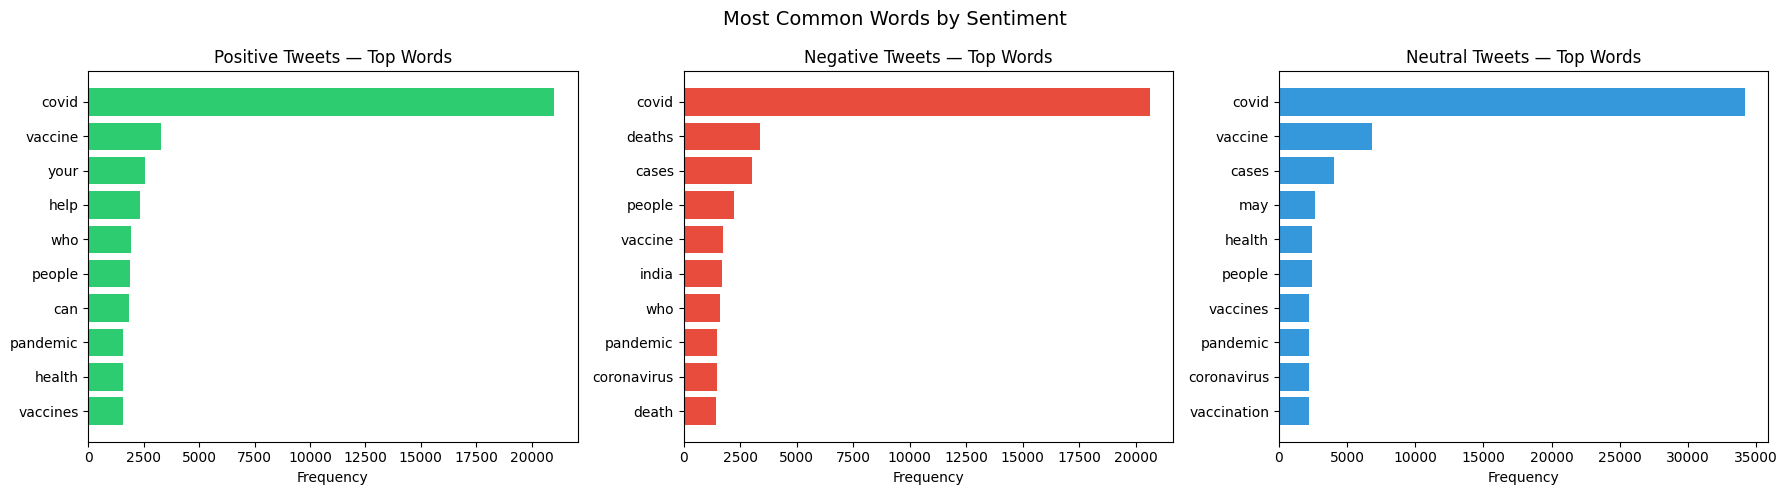

In [78]:
# Step 5 — Find Most Common Words in Each Sentiment
from collections import Counter

# Words to ignore
stopwords = ['the', 'a', 'an', 'is', 'it', 'in', 'on', 'of', 'to',
             'and', 'are', 'for', 'with', 'this', 'that', 'was',
             'we', 'be', 'as', 'at', 'by', 'i', 'you', 'have',
             'not', 'but', 'from', 'or', 'so', 'will', 'my', 'our',
             'they', 'their', 'has', 'he', 'she', 'its', 'been',
             'all', 'more', 'amp', 'get', 'now', 'new']

# Separate tweets by sentiment
pos_tweets = data[data['sentiment'] == 'pos']['clean_text']
neg_tweets = data[data['sentiment'] == 'neg']['clean_text']
neu_tweets = data[data['sentiment'] == 'neu']['clean_text']

# Join all tweets into one string then split into words
pos_words = ' '.join(pos_tweets).split()
neg_words = ' '.join(neg_tweets).split()
neu_words = ' '.join(neu_tweets).split()

# Remove stopwords and short words
pos_clean = [w for w in pos_words if w not in stopwords and len(w) > 2]
neg_clean = [w for w in neg_words if w not in stopwords and len(w) > 2]
neu_clean = [w for w in neu_words if w not in stopwords and len(w) > 2]

# Get top 10 words for each sentiment
pos_top = Counter(pos_clean).most_common(10)
neg_top = Counter(neg_clean).most_common(10)
neu_top = Counter(neu_clean).most_common(10)

# Plot all 3 charts side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Positive chart
pos_words_list  = [w[0] for w in pos_top]
pos_counts_list = [w[1] for w in pos_top]
axes[0].barh(pos_words_list[::-1], pos_counts_list[::-1], color='#2ecc71')
axes[0].set_title('Positive Tweets — Top Words')
axes[0].set_xlabel('Frequency')

# Negative chart
neg_words_list  = [w[0] for w in neg_top]
neg_counts_list = [w[1] for w in neg_top]
axes[1].barh(neg_words_list[::-1], neg_counts_list[::-1], color='#e74c3c')
axes[1].set_title('Negative Tweets — Top Words')
axes[1].set_xlabel('Frequency')

# Neutral chart
neu_words_list  = [w[0] for w in neu_top]
neu_counts_list = [w[1] for w in neu_top]
axes[2].barh(neu_words_list[::-1], neu_counts_list[::-1], color='#3498db')
axes[2].set_title('Neutral Tweets — Top Words')
axes[2].set_xlabel('Frequency')

plt.suptitle('Most Common Words by Sentiment', fontsize=14)
plt.tight_layout()
plt.show()

## Step 6 — Prepare Features and Target for Classification

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Use the actual cleaned tweet text as input
y = data['sentiment']

# TF-IDF converts each tweet into numbers based on words
# max_features=500 means we only keep the top 500 most useful words
vectorizer = TfidfVectorizer(max_features=500)
# build TF‑IDF features from the cl
# eaned text column
X = vectorizer.fit_transform(data['clean_text'])

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'Classes: {y.unique()}')
print('TF-IDF feature extraction done!')

X shape: (119800, 500)
y shape: (119800,)
Classes: ['pos' 'neg' 'neu']
TF-IDF feature extraction done!


## Step 7 — Train/Test Split

In [80]:
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## Step 9 — Train Classification Model
#### Using Logistic Regression — the right model for predicting categories

In [81]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest works better with TF-IDF word features
model = RandomForestClassifier(n_estimators=10, random_state=42)
model.fit(X_train, y_train)
print('Model training complete!')

Model training complete!


## Step 10 — Predictions

In [82]:
y_pred = model.predict(X_test)

print('Sample Predictions vs Actual:')
comparison = pd.DataFrame({'Actual': list(y_test[:10]), 'Predicted': list(y_pred[:10])})
print(comparison.to_string(index=False))

Sample Predictions vs Actual:
Actual Predicted
   neu       neu
   neu       neu
   pos       neu
   neu       neu
   pos       pos
   neg       neg
   neg       neg
   neu       neu
   neg       neg
   neu       neu


## Step 11 — Evaluation Framework
#### Measuring how accurate and reliable our model is

In [83]:
# Accuracy — overall correctness
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy * 100:.2f}%')

# Classification Report — precision, recall, f1 per class
print('\nDetailed Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))

Model Accuracy: 70.38%

Detailed Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.51      0.60      5809
     Neutral       0.67      0.88      0.76     10818
    Positive       0.80      0.60      0.68      7333

    accuracy                           0.70     23960
   macro avg       0.72      0.66      0.68     23960
weighted avg       0.72      0.70      0.70     23960



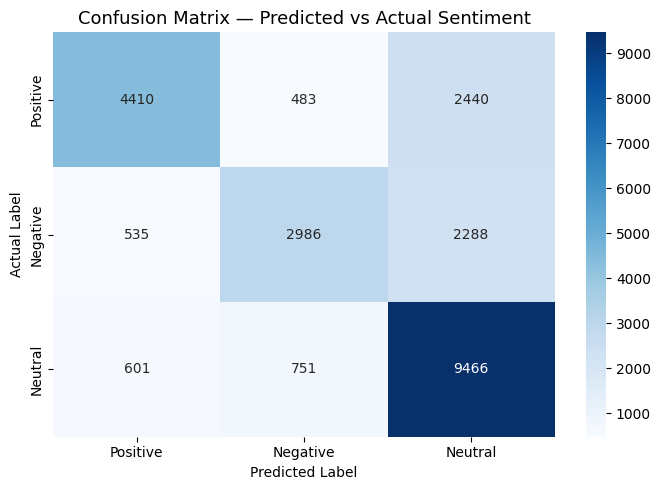

In [84]:
# Confusion Matrix — shows where the model got confused
cm = confusion_matrix(y_test, y_pred, labels=['pos', 'neg', 'neu'])

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Positive', 'Negative', 'Neutral'],
            yticklabels=['Positive', 'Negative', 'Neutral'])
plt.title('Confusion Matrix — Predicted vs Actual Sentiment', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

## Step 12 — Final Summary

In [86]:
print('COVID-19 Sentiment Analysis — Final Summary')
print('=' * 52)
print(f'  Total Tweets Analyzed  : {len(data)}')
print(f'  Training Samples       : {X_train.shape[0]}')
print(f'  Testing Samples        : {X_test.shape[0]}')
print(f'  Model Used             : Random Forest Classifier')
print(f'  Features Used          : {X.shape[1]}')
print(f'  Model Accuracy         : {accuracy * 100:.2f}%')
print('=' * 52)
print('\nSentiment Distribution:')
for label, count in data['sentiment'].value_counts().items():
    pct = count / len(data) * 100
    name = 'Positive' if label == 'pos' else ('Negative' if label == 'neg' else 'Neutral')
    print(f'  {name:<10}: {count:>6} tweets ({pct:.1f}%)')
print('=' * 52)
print('Analysis Complete!')

COVID-19 Sentiment Analysis — Final Summary
  Total Tweets Analyzed  : 119800
  Training Samples       : 95840
  Testing Samples        : 23960
  Model Used             : Random Forest Classifier
  Features Used          : 500
  Model Accuracy         : 70.38%

Sentiment Distribution:
  Neutral   :  54088 tweets (45.1%)
  Positive  :  36668 tweets (30.6%)
  Negative  :  29044 tweets (24.2%)
Analysis Complete!
